<a href="https://colab.research.google.com/github/Megeeee/AgenticAI/blob/AntrophicAgent/AnthrophicAPIAgent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install anthropic
!pip install nnunetv2

import anthropic

client = anthropic.Anthropic(api_key="")

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Define your tools (these wrap your PyTorch models)
tools = [
     {
        "name": "classify_digit",
        "description": "Classify a handwritten digit (0-9) in a local image using a trained "
                    "MNIST CNN. Returns the predicted digit, confidence, and the full "
                    "probability distribution over all 10 classes.",
        "input_schema": {
            "type": "object",
            "properties": {
                "image_path": {"type": "string", "description": "Path to the image file"}
            },
            "required": ["image_path"]
        },

    },
    {
        "name": "classify_cxr",
        "description": "Run chest X-ray classifier. Returns findings with confidence scores.",
        "input_schema": {
            "type": "object",
            "properties": {
                "image_path": {"type": "string", "description": "Path to the DICOM file"}
            }
        }
    },
    {
        "name": "segment_lesion",
        "description": "Segment lesions in the image. Returns mask and measurements.",
        "input_schema": {
            "type": "object",
            "properties": {
                "image_path": {"type": "string"},
                "finding": {"type": "string", "description": "What to segment, e.g. 'nodule'"}
            }
        }
    },
    {
        "name": "search_guidelines",
        "description": "Search radiology guidelines for management recommendations.",
        "input_schema": {
            "type": "object",
            "properties": {
                "query": {"type": "string"}
            }
        }
    }
]

# The agent loop
messages = [
    {"role": "user", "content": (
        "You are a radiology AI assistant. A new chest X-ray has arrived.\n"
        "Clinical context: 55yo male, cough for 3 weeks, smoker.\n"
        "Study path: /studies/patient_123/cxr_001.dcm\n"
        "Analyze this study and produce a structured report."
    )}
]

In [2]:
!pip install torchinfo

In [3]:
import cnn_model
import torch
CNN = cnn_model.CNNModel(28,28).to("cuda")

testdataloader = cnn_model.MNISTtestloaderload()
traindataloader = cnn_model.MNISTtrainloaderload()

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 339kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.1MB/s]


Training on:} NVIDIA A100-SXM4-80GB
[Epoch: 1, Batch: 200] loss: 0.483
[Epoch: 1, Batch: 400] loss: 0.150
[Epoch: 1, Batch: 600] loss: 0.116
[Epoch: 1, Batch: 800] loss: 0.104
[Epoch: 2, Batch: 200] loss: 0.075
[Epoch: 2, Batch: 400] loss: 0.080
[Epoch: 2, Batch: 600] loss: 0.071
[Epoch: 2, Batch: 800] loss: 0.071


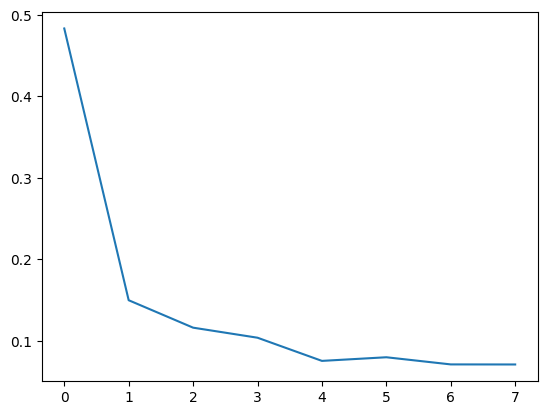

Finished Training


In [4]:
cnn_model.train(CNN,traindataloader,epochsize=2)

In [5]:
from PIL import Image, ImageOps
from torchvision import transforms
import torch.nn.functional as F
import json

In [6]:
preprocess = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),  # MNIST mean/std
])

In [7]:
def classify_digit(image_path: str) -> dict:
    img = Image.open(image_path).convert("L")

    x = preprocess(img).unsqueeze(1).to("cuda")
    with torch.inference_mode():
        probs = F.softmax(CNN(x), dim=1)[0]

    return {
        "predicted_digit": int(probs.argmax().item()),
        "confidence": round(probs.max().item(), 4),
        "all_probabilities": {
            str(d): round(p.item(), 4) for d, p in enumerate(probs)
        },
    }


In [8]:
TOOL_REGISTRY = {"classify_digit": classify_digit}

In [9]:
def chat(user_prompt: str) -> str:
   messages = [{"role": "user", "content": user_prompt}]

   while True:
        resp = client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=1024,
            tools=tools,
            messages=messages,
        )
        messages.append({"role": "assistant", "content": resp.content})

        if resp.stop_reason != "tool_use":
            return "".join(b.text for b in resp.content if b.type == "text")

        results = []
        for block in resp.content:
            if block.type == "tool_use":
                try:
                    out = TOOL_REGISTRY[block.name](**block.input)
                except Exception as e:
                    out = {"error": str(e)}

                results.append({
                    "type": "tool_result",
                    "tool_use_id": block.id,
                    "content": json.dumps(out),
                })
        messages.append({"role": "user", "content": results})

In [ ]:
if __name__ == "__main__":
    print(chat(
        "I have a handwritten digit at /content/1056.png "
        "and /content/1232.png What digit are they, and how confident are you? I think all the iamges are 2"
    ))

Here are the results for both images:

| Image | Predicted Digit | Confidence | Notes |
|---|---|---|---|
| `/content/1056.png` | **2** ✅ | **100%** | Perfect confidence! |
| `/content/1232.png` | **4** ❌ | **92.34%** | Differs from your expectation |

### Details:

1. **1056.png** — Predicted as **2** with 100% confidence. The model is completely certain, and this matches your expectation! ✅

2. **1232.png** — Predicted as **4** with **92.34%** confidence. This **does not match** your guess of `2`. ❌ The model also considered:
   - **9** as a possibility with 7.53% probability
   - **8** with a very small 0.13% probability

   You may want to double-check this image — it's possible the handwriting resembles a **4** more than a **2**. Could there be ambiguity in how the digit was written?


In [11]:
import os, torch, numpy as np, nibabel as nib, tempfile

os.environ['nnUNet_raw']          = '/content/nnUNet_raw'
os.environ['nnUNet_preprocessed'] = '/content/nnUNet_preprocessed'
os.environ['nnUNet_results']      = '/content/nnUNet_results'

In [12]:
from nnunettool import *

In [13]:
nnUNet = init_nnUnet(model_training_output_dir ="/content/drive/MyDrive/nnunet_brats_model/Dataset001_BraTS2020/nnUNetTrainer_250epochs__nnUNetPlans__3d_fullres")

In [14]:
def segmentTool(flair_path, t1_path, t1ce_path, t2_path):
  return segment(nnUNet,flair_path, t1_path, t1ce_path, t2_path)

In [10]:
tools = [
     {
        "name": "MRI_segmenter",
        "description": "Segment the tumors in brain MRI",
        "input_schema": {
            "type": "object",
            "properties": {
                 "flair_path": {"type": "string"},
                  "t1_path":    {"type": "string"},
                  "t1ce_path":  {"type": "string"},
                  "t2_path":    {"type": "string"},
            },
            "required": ["flair_path", "t1_path", "t1ce_path", "t2_path"]
        },

    },
     {
        "name": "classify_digit",
        "description": "Classify a handwritten digit (0-9) in a local image using a trained "
                    "MNIST CNN. Returns the predicted digit, confidence, and the full "
                    "probability distribution over all 10 classes.",
        "input_schema": {
            "type": "object",
            "properties": {
                "image_path": {"type": "string", "description": "Path to the image file"}
            },
            "required": ["image_path"]
        },

    },
    {
        "name": "classify_cxr",
        "description": "Run chest X-ray classifier. Returns findings with confidence scores.",
        "input_schema": {
            "type": "object",
            "properties": {
                "image_path": {"type": "string", "description": "Path to the DICOM file"}
            }
        }
    },
    {
        "name": "segment_lesion",
        "description": "Segment lesions in the image. Returns mask and measurements.",
        "input_schema": {
            "type": "object",
            "properties": {
                "image_path": {"type": "string"},
                "finding": {"type": "string", "description": "What to segment, e.g. 'nodule'"}
            }
        }
    },
    {
        "name": "search_guidelines",
        "description": "Search radiology guidelines for management recommendations.",
        "input_schema": {
            "type": "object",
            "properties": {
                "query": {"type": "string"}
            }
        }
    }
]

# The agent loop
messages = [
    {"role": "user", "content": (
        "You are a radiology AI assistant. A new chest X-ray has arrived.\n"
        "Clinical context: 55yo male, cough for 3 weeks, smoker.\n"
        "Study path: /studies/patient_123/cxr_001.dcm\n"
        "Analyze this study and produce a structured report."
    )}
]

In [15]:
TOOL_REGISTRY = {"classify_digit": classify_digit,"MRI_segmenter":segmentTool}

In [16]:
def chat(user_prompt: str) -> str:
   messages = [{"role": "user", "content": user_prompt}]

   while True:
        resp = client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=1024,
            tools=tools,
            messages=messages,
        )
        messages.append({"role": "assistant", "content": resp.content})

        if resp.stop_reason != "tool_use":
            return "".join(b.text for b in resp.content if b.type == "text")

        results = []
        for block in resp.content:
            if block.type == "tool_use":
                try:
                    out = TOOL_REGISTRY[block.name](**block.input)
                except Exception as e:
                    out = {"error": str(e)}

                results.append({
                    "type": "tool_result",
                    "tool_use_id": block.id,
                    "content": json.dumps(out),
                })
        messages.append({"role": "user", "content": results})

In [19]:
if __name__ == "__main__":
    print(chat(
        "I have a brain MRI image at /content/drive/MyDrive/BraTS20_Training_001 "
        "This file contains flair, t1, t1ce, and t2 files. Their names are BraTS20_Training_001_+(flair, t1, t1ce, t2)+.nii"
        "Give details about that patient"
    ))

There are 1 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 1 cases that I would like to predict

Predicting case:
perform_everything_on_device: True


100%|██████████| 8/8 [00:14<00:00,  1.79s/it]


sending off prediction to background worker for resampling and export
done with case
Here is a comprehensive breakdown of the patient's brain MRI findings from **BraTS20_Training_001**:

---

## 🧠 Brain MRI Tumor Segmentation Report

### 📁 Input Modalities Used
| Modality | File |
|---|---|
| **FLAIR** | BraTS20_Training_001_flair.nii |
| **T1** | BraTS20_Training_001_t1.nii |
| **T1 Contrast-Enhanced** | BraTS20_Training_001_t1ce.nii |
| **T2** | BraTS20_Training_001_t2.nii |

---

### 📊 Tumor Volume Measurements

| Tumor Region | Volume (cm³) | Clinical Significance |
|---|---|---|
| 🔴 **Whole Tumor** | **211.56 cm³** | Total tumor extent including all sub-regions |
| 🟠 **Tumor Core** | **43.03 cm³** | Active/necrotic core (non-infiltrative region) |
| 🟡 **Enhancing Tumor** | **27.93 cm³** | Actively proliferating, blood-brain barrier breakdown |

---

### 🔍 Clinical Interpretation

#### 1. 🧩 Whole Tumor — 211.56 cm³
- This is a **very large tumor**, significantly above the average g